# Valores Aleatorios 

Andrea Gutiérrez Rentería

14/09/2026

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [31]:
S0=100
K=110
r=.05
sigma=0.20
T=1
n=252
M=50

In [32]:
dt = T/n

In [33]:
S = np.zeros((n + 1, M))

In [34]:
S[0, :] = S0

for t in range(n):
    Z = np.random.normal(0, 1, M)
    S[t + 1, :] = S[t, :] * np.exp((r - 0.5 * sigma ** 2) * dt + sigma * np.sqrt(dt) * Z)

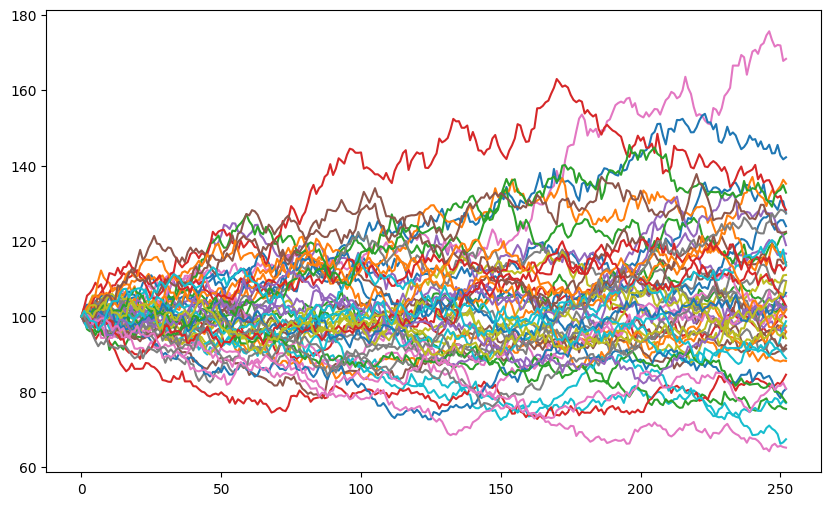

In [35]:
plt.figure(figsize=(10,6))
plt.plot(S);

In [36]:
limite_inferior = np.percentile(S, 2.5, axis=1)
limite_superior = np.percentile(S, 97.5, axis=1)
promedio = np.mean(S, axis=1)

dias = np.arange(n + 1)

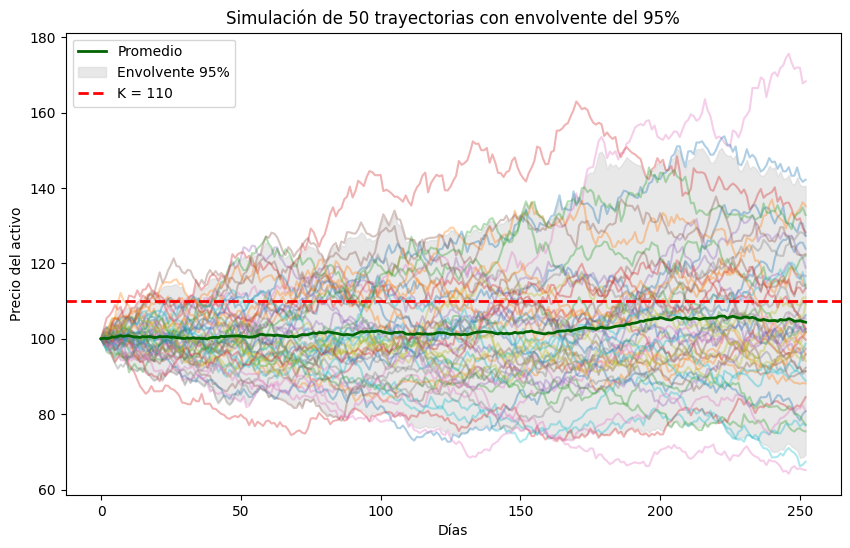

In [37]:
plt.figure(figsize=(10,6))

plt.plot(dias, S, alpha=0.35)

plt.plot(
    dias,
    promedio,
    linewidth=2,
    label="Promedio",
    color="darkgreen"
)

plt.fill_between(
    dias,
    limite_inferior,
    limite_superior,
    color="lightgray",
    alpha=0.5,
    label="Envolvente 95%"
)

plt.axhline(
    y=K,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"K = {K}"
)

plt.xlabel("Días")
plt.ylabel("Precio del activo")
plt.title("Simulación de 50 trayectorias con envolvente del 95%")
plt.legend()

plt.show()

In [38]:
M = 1000

ST = []
S_promedio = []

for j in range(M):

    precios = [S0]

    for i in range(n):

        Z = np.random.normal(0, 1)

        S_nuevo = precios[-1] * np.exp(
            (r - 0.5 * sigma**2) * dt
            + sigma * np.sqrt(dt) * Z
        )

        precios.append(S_nuevo)

    ST.append(precios[-1])
    S_promedio.append(np.mean(precios[1:]))

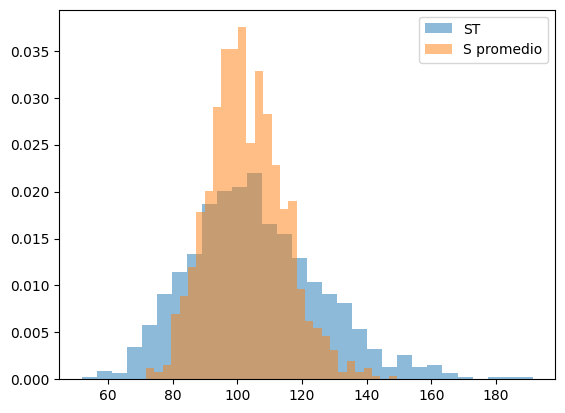

In [39]:
plt.hist(ST, bins=30, alpha=0.5, density=True, label="ST")
plt.hist(S_promedio, bins=30, alpha=0.5, density=True, label="S promedio")

plt.legend()
plt.show()

In [40]:
ST = np.array(ST)
promedio_S = np.array(S_promedio)

In [41]:
payoff_europea = np.maximum(ST - K, 0)

payoff_asiatica = np.maximum(promedio_S - K, 0)

promedio_payoff_europea = np.mean(payoff_europea)
promedio_payoff_asiatica = np.mean(payoff_asiatica)

valor_presente_europea = np.exp(-r*T) * promedio_payoff_europea
valor_presente_asiatica = np.exp(-r*T) * promedio_payoff_asiatica

In [42]:
tabla_opciones = pd.DataFrame({
    "Tipo de opción": ["Europea", "Asiática"],
    "Payoff promedio": [
        promedio_payoff_europea,
        promedio_payoff_asiatica
    ],
    "Valor presente": [
        valor_presente_europea,
        valor_presente_asiatica
    ]
})

tabla_opciones

,Tipo de opción,Payoff promedio,Valor presente
0,Europea,6.219607,5.916273
1,Asiática,2.060762,1.960257


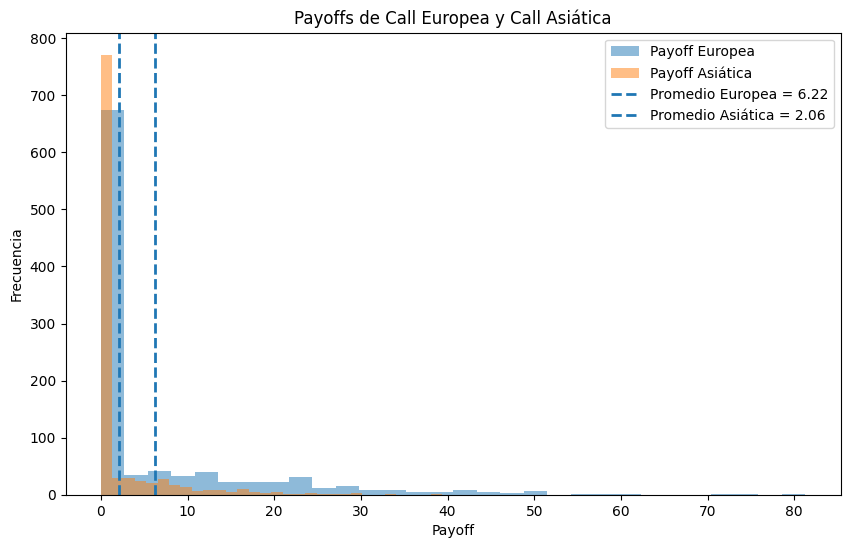

In [43]:
plt.figure(figsize=(10,6))

plt.hist(
    payoff_europea,
    bins=30,
    alpha=0.5,
    label="Payoff Europea"
)

plt.hist(
    payoff_asiatica,
    bins=30,
    alpha=0.5,
    label="Payoff Asiática"
)

plt.axvline(
    promedio_payoff_europea,
    linestyle="--",
    linewidth=2,
    label=f"Promedio Europea = {promedio_payoff_europea:.2f}"
)

plt.axvline(
    promedio_payoff_asiatica,
    linestyle="--",
    linewidth=2,
    label=f"Promedio Asiática = {promedio_payoff_asiatica:.2f}"
)

plt.xlabel("Payoff")
plt.ylabel("Frecuencia")
plt.title("Payoffs de Call Europea y Call Asiática")
plt.legend()

plt.show()